# Eligible-trajectory hopping geometries

Plot the geometry at each MCH hop from the 29 eligible azobenzene trajectories. Coordinates are the C–N=N–C dihedral, N=N distance, and N=N–C angle.

In [3]:
from pathlib import Path
import math
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEARCH_ROOT = Path("sharc") if Path("sharc").is_dir() else Path(".")
TRAJ_GLOB = "structure_0006/traj-allmols/**/TRAJ_*"
DIHEDRAL_ATOMS = (4, 5, 6, 7)  # 1-based C-N=N-C
NN_ATOMS = (5, 6)
NNC_ANGLE_ATOMS = (5, 6, 7)
GROUND_MCH_STATE = 1
NN_BOND_MIN_ANGSTROM = 0.9
NN_BOND_EXCLUSION_ANGSTROM = 3.0


def parse_xyz_lines(lines, source):
    frames, position = [], 0
    while position < len(lines):
        while position < len(lines) and not lines[position].strip():
            position += 1
        if position == len(lines):
            break
        try:
            n_atoms = int(lines[position])
        except ValueError as error:
            raise ValueError(f"{source}: invalid XYZ atom count at line {position + 1}") from error
        if n_atoms <= 0 or position + n_atoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete XYZ frame")
        coordinates = []
        for line in lines[position + 2 : position + n_atoms + 2]:
            fields = line.split()
            if len(fields) < 4:
                raise ValueError(f"{source}: malformed XYZ atom row")
            coordinates.append([float(value) for value in fields[1:4]])
        frames.append(np.asarray(coordinates, dtype=float))
        position += n_atoms + 2
    if not frames:
        raise ValueError(f"{source}: no XYZ frames")
    return frames


def signed_dihedral_deg(coordinates, atom_indices):
    indices = np.asarray(atom_indices, dtype=int) - 1
    p0, p1, p2, p3 = coordinates[indices]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1 /= np.linalg.norm(b1)
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    return math.degrees(math.atan2(np.dot(np.cross(b1, v), w), np.dot(v, w))) % 360.0


def cis_trans_label(dihedral_deg):
    return "cis" if min(dihedral_deg, 360.0 - dihedral_deg) <= 90.0 else "trans"


def bond_length_angstrom(coordinates, atom_indices):
    first, second = np.asarray(atom_indices, dtype=int) - 1
    return float(np.linalg.norm(coordinates[first] - coordinates[second]))


def nnc_angle_deg(coordinates, atom_indices=NNC_ANGLE_ATOMS):
    first, vertex, third = coordinates[np.asarray(atom_indices, dtype=int) - 1]
    first_vector, third_vector = first - vertex, third - vertex
    cosine = np.clip(
        np.dot(first_vector, third_vector) / (np.linalg.norm(first_vector) * np.linalg.norm(third_vector)),
        -1.0, 1.0,
    )
    return float(math.degrees(math.acos(cosine)))


def lis_times_and_states(lis_path):
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or any(len(row) < 4 for row in rows):
        raise ValueError(f"{lis_path}: no valid output.lis rows")
    return np.asarray([float(row[1]) for row in rows]), np.asarray([int(row[3]) for row in rows])


hop_records = []
trajectory_dirs = sorted(path for path in SEARCH_ROOT.glob(TRAJ_GLOB) if path.is_dir())
for trajectory_dir in trajectory_dirs:
    xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
    if not xyz_path.is_file() or not lis_path.is_file():
        continue
    frames = parse_xyz_lines(xyz_path.read_text(encoding="utf-8").splitlines(), str(xyz_path))
    times_fs, states = lis_times_and_states(lis_path)
    if len(frames) != len(states):
        raise ValueError(f"{trajectory_dir}: XYZ/MCH-state frame count mismatch")

    nn_lengths = np.asarray([bond_length_angstrom(frame, NN_ATOMS) for frame in frames])
    eligible = (
        states[-1] == GROUND_MCH_STATE
        and nn_lengths.min() >= NN_BOND_MIN_ANGSTROM
        and nn_lengths.max() <= NN_BOND_EXCLUSION_ANGSTROM
    )
    if not eligible:
        continue

    initial_label = cis_trans_label(signed_dihedral_deg(frames[0], DIHEDRAL_ATOMS))
    final_label = cis_trans_label(signed_dihedral_deg(frames[-1], DIHEDRAL_ATOMS))
    trajectory_outcome = "reactive" if initial_label != final_label else "nonreactive"

    hop_indices = np.flatnonzero(states[1:] != states[:-1]) + 1
    for hop_index in hop_indices:
        coordinates = frames[hop_index]
        hop_records.append({
            "trajectory": trajectory_dir.name,
            "time_fs": times_fs[hop_index],
            "from_mch_state": states[hop_index - 1],
            "to_mch_state": states[hop_index],
            "outcome": trajectory_outcome,
            "dihedral_deg": signed_dihedral_deg(coordinates, DIHEDRAL_ATOMS),
            "nn_bond_length_angstrom": nn_lengths[hop_index],
            "nnc_angle_deg": nnc_angle_deg(coordinates),
        })

hops = pd.DataFrame(hop_records).sort_values(["trajectory", "time_fs"]).reset_index(drop=True)
print(f"Found {len(hops)} hops in eligible trajectories.")
if len(hops) != 29:
    warnings.warn(f"Expected 29 eligible hops, found {len(hops)}.")
display(hops)

Found 29 hops in eligible trajectories.


,trajectory,time_fs,from_mch_state,to_mch_state,outcome,dihedral_deg,nn_bond_length_angstrom,nnc_angle_deg
0,TRAJ_00002,313.0,2,1,nonreactive,186.044456,1.480855,111.570189
1,TRAJ_00008,532.5,2,1,nonreactive,266.953030,1.232790,125.195149
2,TRAJ_00009,323.0,2,1,nonreactive,204.461198,1.255937,128.256719
3,TRAJ_00010,598.0,2,1,reactive,262.236508,1.205140,129.104010
4,TRAJ_00012,780.0,2,1,reactive,293.265605,1.236981,137.030831
5,TRAJ_00015,481.0,2,1,nonreactive,241.628345,1.233345,127.758048
6,TRAJ_00017,650.5,2,1,nonreactive,176.416674,1.366724,120.785500
7,TRAJ_00025,183.0,2,1,nonreactive,174.320487,1.542857,110.945485
8,TRAJ_00026,818.0,2,1,reactive,288.496777,1.213872,133.525422
9,TRAJ_00029,129.5,2,1,nonreactive,169.548457,1.388674,111.509208


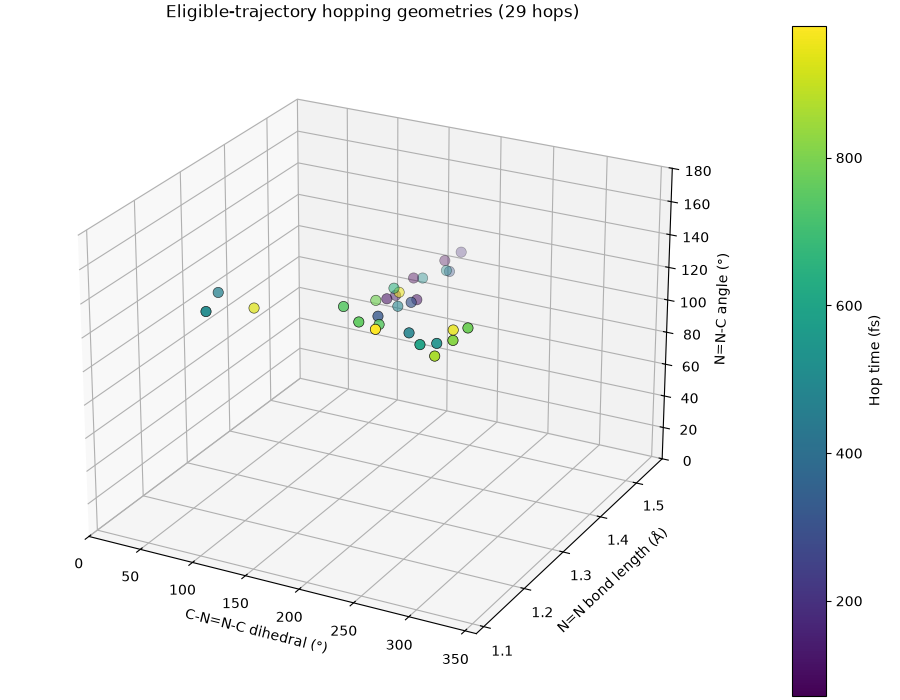

In [4]:
%matplotlib widget

fig = plt.figure(figsize=(9, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

points = ax.scatter(
    hops["dihedral_deg"], hops["nn_bond_length_angstrom"], hops["nnc_angle_deg"],
    c=hops["time_fs"], cmap="viridis", s=55, edgecolors="black", linewidths=0.45,
)
#for row in hops.itertuples():
#    ax.text(row.dihedral_deg, row.nn_bond_length_angstrom, row.nnc_angle_deg,
#            row.trajectory.removeprefix("TRAJ_"), fontsize=7)

fig.colorbar(points, ax=ax, pad=0.12, label="Hop time (fs)")
ax.set(
    xlabel="C-N=N-C dihedral (°)", xlim=(0, 360),
    ylabel="N=N bond length (Å)",
    zlabel="N=N-C angle (°)", zlim=(0, 180),
)
ax.view_init(elev=24, azim=-62)
ax.set_title(f"Eligible-trajectory hopping geometries ({len(hops)} hops)")
plt.show()

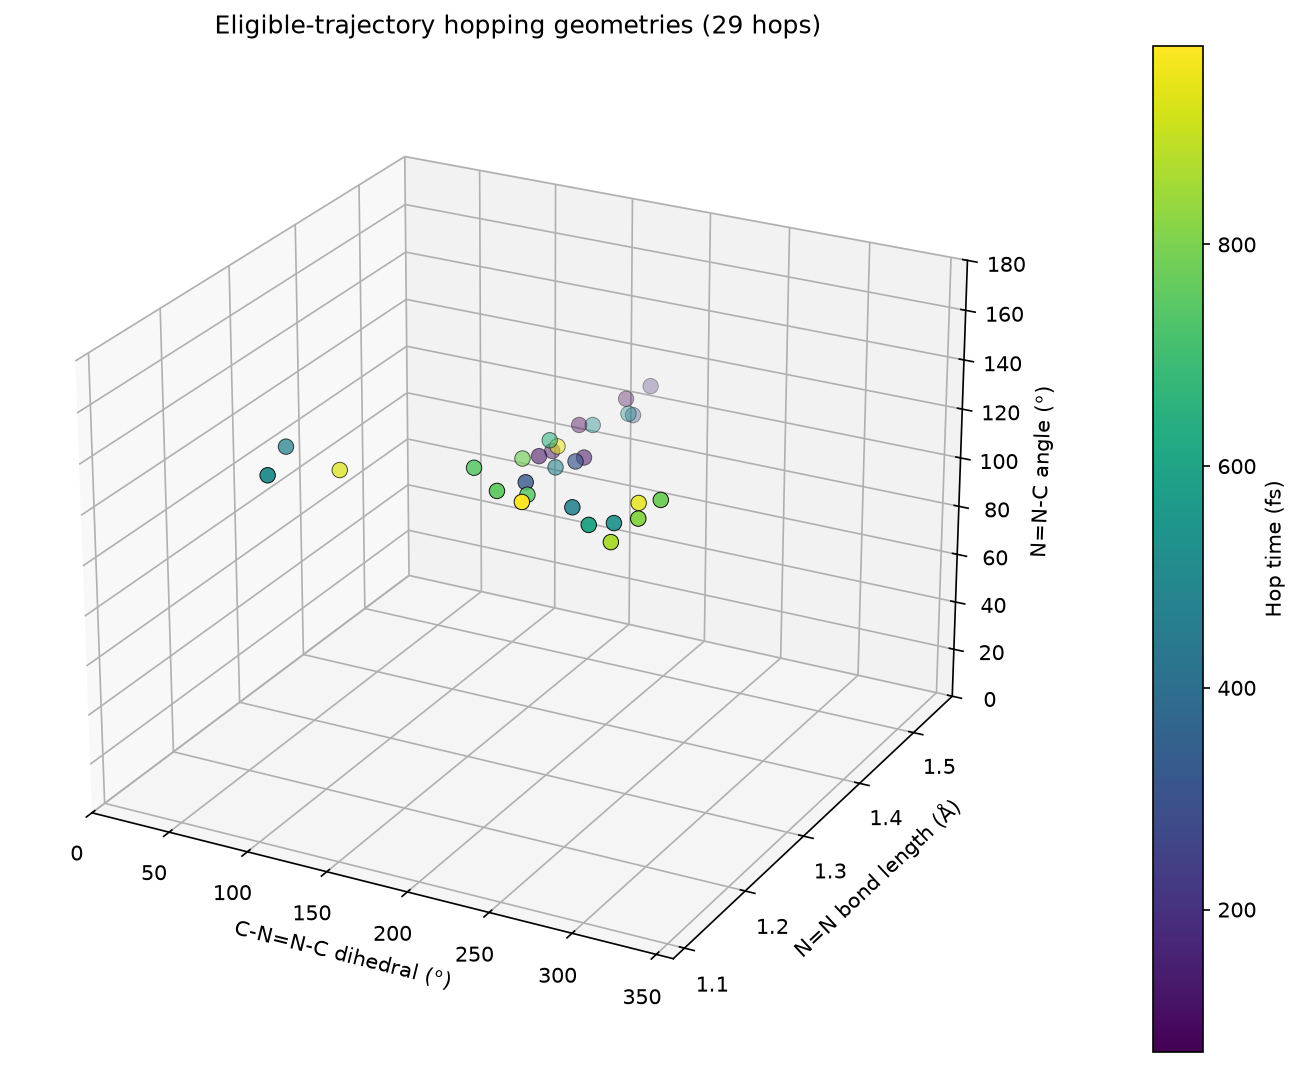

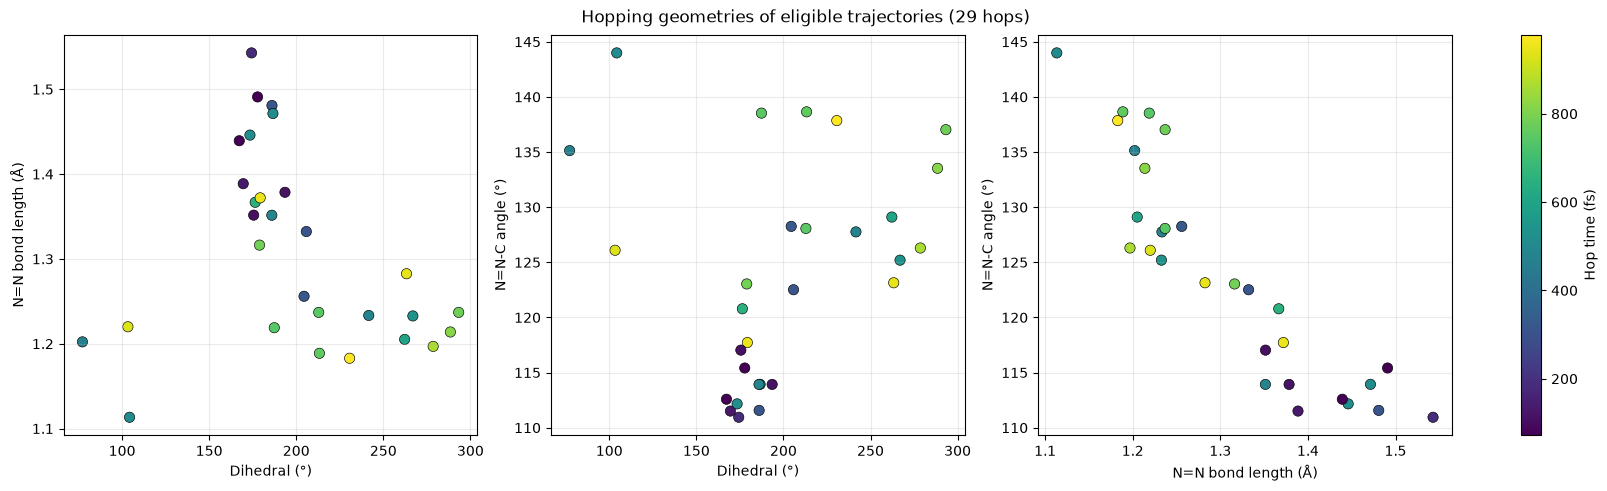

In [5]:
%matplotlib inline

# The same hopping geometries projected onto each pair of coordinates.
coordinate_pairs = [
    ("dihedral_deg", "nn_bond_length_angstrom", "Dihedral (°)", "N=N bond length (Å)"),
    ("dihedral_deg", "nnc_angle_deg", "Dihedral (°)", "N=N-C angle (°)"),
    ("nn_bond_length_angstrom", "nnc_angle_deg", "N=N bond length (Å)", "N=N-C angle (°)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (x_column, y_column, x_label, y_label) in zip(axes, coordinate_pairs):
    points = ax.scatter(
        hops[x_column], hops[y_column], c=hops["time_fs"], cmap="viridis",
        s=55, edgecolors="black", linewidths=0.45,
    )
    ax.set(xlabel=x_label, ylabel=y_label)
    ax.grid(alpha=0.25)

fig.colorbar(points, ax=axes, label="Hop time (fs)")
fig.suptitle(f"Hopping geometries of eligible trajectories ({len(hops)} hops)")
plt.show()

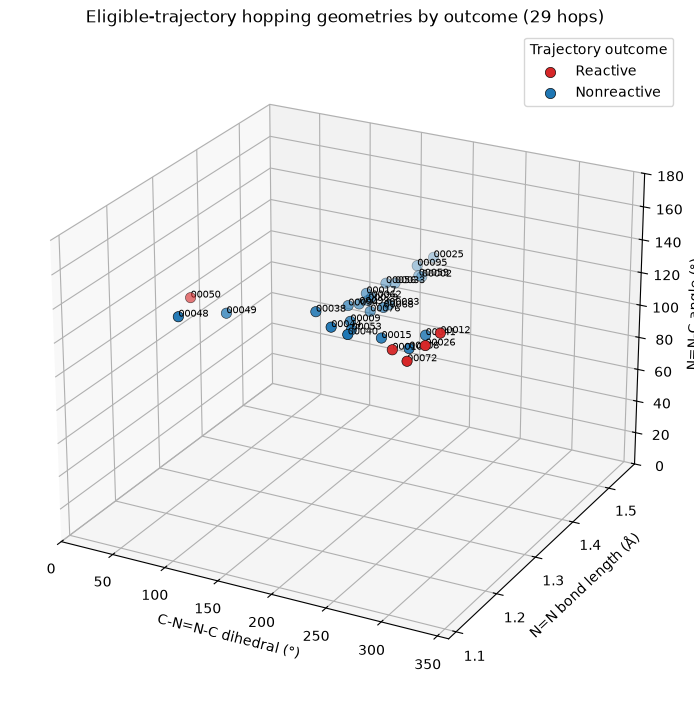

In [5]:
# Duplicate 3D view: colour encodes reactive outcome rather than hop time.
outcome_colours = {"reactive": "tab:red", "nonreactive": "tab:blue"}
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")
for outcome, colour in outcome_colours.items():
    subset = hops[hops["outcome"] == outcome]
    ax.scatter(
        subset["dihedral_deg"], subset["nn_bond_length_angstrom"], subset["nnc_angle_deg"],
        color=colour, s=55, edgecolors="black", linewidths=0.45, label=outcome.capitalize(),
    )
for row in hops.itertuples():
    ax.text(row.dihedral_deg, row.nn_bond_length_angstrom, row.nnc_angle_deg,
            row.trajectory.removeprefix("TRAJ_"), fontsize=7)

ax.set(
    xlabel="C-N=N-C dihedral (°)", xlim=(0, 360),
    ylabel="N=N bond length (Å)",
    zlabel="N=N-C angle (°)", zlim=(0, 180),
)
ax.view_init(elev=24, azim=-62)
ax.legend(title="Trajectory outcome")
ax.set_title(f"Eligible-trajectory hopping geometries by outcome ({len(hops)} hops)")
plt.show()

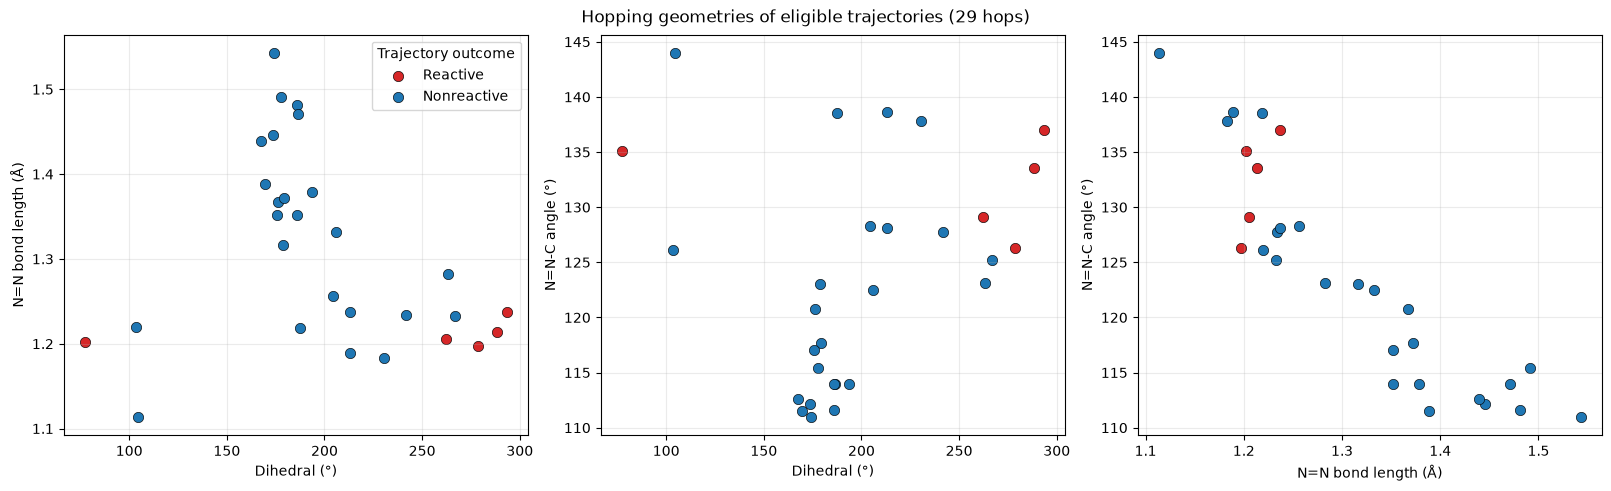

In [7]:
# Duplicate 2D projections: red reactive hops and blue nonreactive hops.
coordinate_pairs = [
    ("dihedral_deg", "nn_bond_length_angstrom", "Dihedral (°)", "N=N bond length (Å)"),
    ("dihedral_deg", "nnc_angle_deg", "Dihedral (°)", "N=N-C angle (°)"),
    ("nn_bond_length_angstrom", "nnc_angle_deg", "N=N bond length (Å)", "N=N-C angle (°)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (x_column, y_column, x_label, y_label) in zip(axes, coordinate_pairs):
    for outcome, colour in outcome_colours.items():
        subset = hops[hops["outcome"] == outcome]
        ax.scatter(
            subset[x_column], subset[y_column], color=colour, s=55, edgecolors="black", linewidths=0.45,
            label=outcome.capitalize(),
        )
    ax.set(xlabel=x_label, ylabel=y_label)
    ax.grid(alpha=0.25)

axes[0].legend(title="Trajectory outcome")
fig.suptitle(f"Hopping geometries of eligible trajectories ({len(hops)} hops)")
plt.show()

## Hopping geometries on the static-grid energy surface

The static grid provides geometries from 0 to 180°. Its energy-gap surface is reflected about 180° to span the full dihedral range.

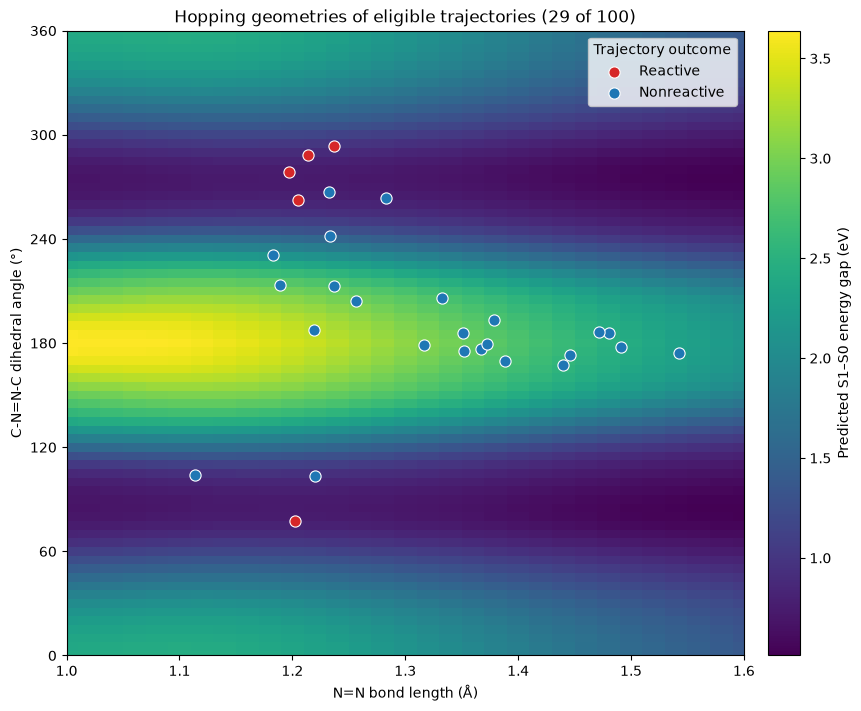

In [6]:
import json

HARTREE_TO_EV = 27.211386245988
GRID_PATHS = (
    Path("data/azoflip_data/XYZ/azobenzene_variable_rotation_grid_static.xyz"),
    Path("../data/azoflip_data/XYZ/azobenzene_variable_rotation_grid_static.xyz"),
)
GRID_PATH = next((path for path in GRID_PATHS if path.is_file()), None)
if GRID_PATH is None:
    raise FileNotFoundError("Could not find azobenzene_variable_rotation_grid_static.xyz")

def static_grid_energy_gap(grid_path):
    records = []
    lines = grid_path.read_text(encoding="utf-8").splitlines()
    position = 0
    while position < len(lines):
        n_atoms = int(lines[position])
        comment = lines[position + 1]
        dihedral = float(re.search(r"cnnc_dihedral_deg=([-+0-9.eE]+)", comment).group(1))
        bond_length = float(re.search(r"nn_distance_angstrom=([-+0-9.eE]+)", comment).group(1))
        energies = json.loads(re.search(r'ReF_energy="_JSON (.*?)"', comment, re.IGNORECASE).group(1))[0]
        records.append((dihedral, bond_length, (energies[1] - energies[0]) * HARTREE_TO_EV))
        position += n_atoms + 2

    grid = pd.DataFrame(records, columns=["dihedral_deg", "nn_bond_length_angstrom", "s1_s0_gap_ev"])
    return grid.pivot(index="dihedral_deg", columns="nn_bond_length_angstrom", values="s1_s0_gap_ev").sort_index().sort_index(axis=1)

energy_grid = static_grid_energy_gap(GRID_PATH)
grid_dihedrals = energy_grid.index.to_numpy()
grid_bond_lengths = energy_grid.columns.to_numpy()

# The source grid covers 0–180°. Reflect it about y = 180° to obtain 180–360°.
reflected_energy_grid = np.vstack([energy_grid.to_numpy(), energy_grid.to_numpy()[-2::-1]])
reflected_dihedrals = np.r_[grid_dihedrals, 360.0 - grid_dihedrals[-2::-1]]

def cell_edges(values):
    midpoints = (values[:-1] + values[1:]) / 2
    return np.r_[values[0] - (midpoints[0] - values[0]), midpoints, values[-1] + (values[-1] - midpoints[-1])]

fig, ax = plt.subplots(figsize=(8.5, 7), constrained_layout=True)
heatmap = ax.pcolormesh(
    cell_edges(grid_bond_lengths), cell_edges(reflected_dihedrals), reflected_energy_grid,
    cmap="viridis", shading="flat", zorder=0,
)

for outcome, colour in outcome_colours.items():
    subset = hops[hops["outcome"] == outcome]
    ax.scatter(
        subset["nn_bond_length_angstrom"], subset["dihedral_deg"],
        color=colour, s=65, edgecolors="white", linewidths=0.8,
        label=outcome.capitalize(), zorder=2,
    )

colorbar = fig.colorbar(heatmap, ax=ax, pad=0.02)
colorbar.set_label("Predicted S1–S0 energy gap (eV)")
ax.set(
    xlabel="N=N bond length (Å)", xlim=(1.0, 1.6),
    ylabel="C-N=N-C dihedral angle (°)", ylim=(0, 360),
    yticks=np.arange(0, 361, 60),
)
# ax.axhline(180, color="white", linestyle="--", linewidth=0.9, alpha=0.75, zorder=1)
ax.legend(title="Trajectory outcome", loc="upper right")
ax.set_title(f"Hopping geometries of eligible trajectories ({len(hops)} of {len(trajectory_dirs)})")
plt.show()